In [5]:
import requests
import pandas as pd
url = "https://apim.laliga.com/webview/api/web/competitions/1/transfers?contentLanguage=en&subscription-key=ee7fcd5c543f4485ba2a48856fc7ece9"
headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
data = response.json()

# Print the keys to understand the structure
print(data.keys())

# Let's assume 'transfers' is the main key for player data
transfers = data.get('transfers', [])

# If you want to see the first item structure
if transfers:
    print(transfers[0])

# Convert to pandas DataFrame for further processing
df = pd.DataFrame(transfers)
print(df)

dict_keys(['transfers'])
{'id': 6371, 'name': 'LAPORTE', 'date': '2025-09-14T00:00:00+00:00', 'team_to': {'slug': 'athletic-club', 'nickname': 'Athletic Club', 'sprite_status': 'created'}, 'team_from_string': 'AL-NASR RIYADH', 'procedure': {'id': 3, 'name': 'Transfer'}, 'nationality_birth': 'ES', 'state': 'validado CMP', 'player': {'name': 'Laporte', 'slug': 'laporte'}}
       id              name                       date  \
0    6371           LAPORTE  2025-09-14T00:00:00+00:00   
1    6347            ALEXIS  2025-09-04T00:00:00+00:00   
2    6369     NICO GONZÁLEZ  2025-09-01T00:00:00+00:00   
3    6367           SOLOMON  2025-09-01T00:00:00+00:00   
4    6365         LIVAKOVIC  2025-09-01T00:00:00+00:00   
..    ...               ...                        ...   
174  5864            JUANLU  2025-07-17T00:00:00+00:00   
175  5861          ALEX . B  2025-07-10T00:00:00+00:00   
176  5857          J. MUSSO  2025-07-01T00:00:00+00:00   
177  5856  ALEXANDER-ARNOLD  2025-07-01T00:00:0

In [6]:
df.head()

,id,name,date,team_to,team_from_string,procedure,nationality_birth,state,player,team_from
0,6371,LAPORTE,2025-09-14T00:00:00+00:00,"{'slug': 'athletic-club', 'nickname': 'Athleti...",AL-NASR RIYADH,"{'id': 3, 'name': 'Transfer'}",ES,validado CMP,"{'name': 'Laporte', 'slug': 'laporte'}",NaN
1,6347,ALEXIS,2025-09-04T00:00:00+00:00,"{'slug': 'sevilla-fc', 'nickname': 'Sevilla FC...",NaN,"{'id': 1, 'name': 'Free'}",CL,validado CMP,"{'name': 'Alexis', 'slug': 'alexis-sanchez'}","{'slug': 'udinese', 'nickname': 'Udinese', 'sp..."
2,6369,NICO GONZÁLEZ,2025-09-01T00:00:00+00:00,"{'slug': 'atletico-de-madrid', 'nickname': 'At...",NaN,"{'id': 2, 'name': 'Loan'}",AR,validado CMP,NaN,"{'slug': 'juventus', 'nickname': 'Juventus', '..."
3,6367,SOLOMON,2025-09-01T00:00:00+00:00,"{'slug': 'villarreal-cf', 'nickname': 'Villarr...",NaN,"{'id': 2, 'name': 'Loan'}",IL,validado CMP,NaN,"{'slug': 'tottenham', 'nickname': 'Spurs', 'sh..."
4,6365,LIVAKOVIC,2025-09-01T00:00:00+00:00,"{'slug': 'girona-fc', 'nickname': 'Girona FC',...",NaN,"{'id': 2, 'name': 'Loan'}",HR,validado CMP,NaN,"{'slug': 'fenerbahce', 'nickname': 'Fenerbahçe..."


In [ ]:
def extract_club_name(club_dict):
    if isinstance(club_dict, dict):
        return club_dict.get('nickname', club_dict.get('slug', None))
    return club_dict

def extract_procedure(proc_dict):
    if isinstance(proc_dict, dict):
        return proc_dict.get('name', None)
    return proc_dict


df_clean = pd.DataFrame({
    'id': df['id'],
    'name': df['name'],
    'date': df['date'],
    'team_from_string': df['team_from_string'],
    'team_from': df['team_from'].apply(extract_club_name),
    'team_to': df['team_to'].apply(extract_club_name),
    'procedure': df['procedure'].apply(extract_procedure),
    'nationality_birth': df['nationality_birth'],
})

print(df_clean)

       id              name                       date team_from_string  \
0    6371           LAPORTE  2025-09-14T00:00:00+00:00   AL-NASR RIYADH   
1    6347            ALEXIS  2025-09-04T00:00:00+00:00              NaN   
2    6369     NICO GONZÁLEZ  2025-09-01T00:00:00+00:00              NaN   
3    6367           SOLOMON  2025-09-01T00:00:00+00:00              NaN   
4    6365         LIVAKOVIC  2025-09-01T00:00:00+00:00              NaN   
..    ...               ...                        ...              ...   
174  5864            JUANLU  2025-07-17T00:00:00+00:00              NaN   
175  5861          ALEX . B  2025-07-10T00:00:00+00:00              NaN   
176  5857          J. MUSSO  2025-07-01T00:00:00+00:00              NaN   
177  5856  ALEXANDER-ARNOLD  2025-07-01T00:00:00+00:00              NaN   
178  5855           HUIJSEN  2025-07-01T00:00:00+00:00              NaN   

         team_from             team_to procedure nationality_birth  
0              NaN       Athle

In [9]:
df_clean.head()

,id,name,date,team_from_string,team_from,team_to,procedure,nationality_birth
0,6371,LAPORTE,2025-09-14T00:00:00+00:00,AL-NASR RIYADH,NaN,Athletic Club,Transfer,ES
1,6347,ALEXIS,2025-09-04T00:00:00+00:00,NaN,Udinese,Sevilla FC,Free,CL
2,6369,NICO GONZÁLEZ,2025-09-01T00:00:00+00:00,NaN,Juventus,Atlético de Madrid,Loan,AR
3,6367,SOLOMON,2025-09-01T00:00:00+00:00,NaN,Spurs,Villarreal CF,Loan,IL
4,6365,LIVAKOVIC,2025-09-01T00:00:00+00:00,NaN,Fenerbahçe,Girona FC,Loan,HR


In [10]:
df_clean['date'] = pd.to_datetime(df['date']).dt.strftime('%y-%m-%d')
df_clean.head()

df_clean.to_csv('transfers_laliga.csv')

In [11]:
import requests
import pandas as pd
url = "https://apim.laliga.com/webview/api/web/subscriptions/laliga-easports-2025/standing?&contentLanguage=en&subscription-key=ee7fcd5c543f4485ba2a48856fc7ece9"
headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
data = response.json()

# Print the keys to understand the structure
print(data.keys())


dict_keys(['standings'])


In [12]:
standing = data.get('standings', [])

# If you want to see the first item structure
if standing:
    print(standing[0])

# Convert to pandas DataFrame for further processing
df1 = pd.DataFrame(standing)
print(df1)

{'played': 8, 'points': 21, 'won': 7, 'drawn': 0, 'lost': 1, 'goals_for': 19, 'goals_against': 9, 'goal_difference': '+10', 'position': 1, 'previous_position': 1, 'difference_position': 0, 'team': {'id': 15, 'slug': 'real-madrid', 'name': 'Real Madrid Club de Fútbol', 'nickname': 'Real Madrid', 'boundname': 'Real Madrid', 'shortname': 'RMA', 'sprite_status': 'created', 'shield': {'id': 149}, 'competitions': []}, 'qualify': {'name': 'Champions League', 'shortname': 'Champions League', 'color': '#08237f'}}
    played  points  won  drawn  lost  goals_for  goals_against  \
0        8      21    7      0     1         19              9   
1        8      19    6      1     1         22              9   
2        8      16    5      1     2         14              8   
3        8      15    4      3     1         13              8   
4        8      13    3      4     1         15             10   
5        8      13    4      1     3         15             11   
6        8      13    3     

In [13]:
df1.head()

,played,points,won,drawn,lost,goals_for,goals_against,goal_difference,position,previous_position,difference_position,team,qualify
0,8,21,7,0,1,19,9,+10,1,1,0,"{'id': 15, 'slug': 'real-madrid', 'name': 'Rea...","{'name': 'Champions League', 'shortname': 'Cha..."
1,8,19,6,1,1,22,9,+13,2,2,0,"{'id': 4, 'slug': 'fc-barcelona', 'name': 'Fút...","{'name': 'Champions League', 'shortname': 'Cha..."
2,8,16,5,1,2,14,8,+6,3,3,0,"{'id': 20, 'slug': 'villarreal-cf', 'name': 'V...","{'name': 'Champions League', 'shortname': 'Cha..."
3,8,15,4,3,1,13,8,+5,4,4,0,"{'id': 5, 'slug': 'real-betis', 'name': 'Real ...","{'name': 'Champions League', 'shortname': 'Cha..."
4,8,13,3,4,1,15,10,+5,5,5,0,"{'id': 2, 'slug': 'atletico-de-madrid', 'name'...","{'name': 'Champions League', 'shortname': 'Cha..."


In [ ]:
def extract_club_name(club_dict):
    if isinstance(club_dict, dict):
        return club_dict.get('nickname', club_dict.get('slug', None))
    return club_dict

def extract_qualify(qualify_dict):
    if isinstance(qualify_dict, dict):
        return qualify_dict.get('name', None)
    return qualify_dict



df1_clean = pd.DataFrame({
    'Position': df1['position'],
    'Team': df1['team'].apply(extract_club_name),
    'Played': df1['played'],
    'Qualify': df1['qualify'].apply(extract_qualify),
})

print(df1_clean)

    Position                       Team  Played            Qualify
0          1                Real Madrid       8   Champions League
1          2               FC Barcelona       8   Champions League
2          3              Villarreal CF       8   Champions League
3          4                 Real Betis       8   Champions League
4          5         Atlético de Madrid       8   Champions League
5          6                 Sevilla FC       8      Europa League
6          7                   Elche CF       8      Europa League
7          8              Athletic Club       8  Conference League
8          9  RCD Espanyol de Barcelona       8                NaN
9         10           Deportivo Alavés       8                NaN
10        11                  Getafe CF       8                NaN
11        12                 CA Osasuna       8                NaN
12        13                 Levante UD       8                NaN
13        14             Rayo Vallecano       8               

In [15]:
df1_clean.head()
df1_clean.to_csv('standing_laliga.csv')

In [16]:
df_free = df_clean[df_clean['procedure'] == 'Free']
df_free.head()

,id,name,date,team_from_string,team_from,team_to,procedure,nationality_birth
1,6347,ALEXIS,25-09-04,NaN,Udinese,Sevilla FC,Free,CL
16,6333,DIANG,25-09-01,NaN,West Brom,Elche CF,Free,CD
18,6320,A. ABQAR,25-09-01,NaN,Deportivo Alavés,Getafe CF,Free,MA
19,6319,MARC BERNAL,25-09-01,FC BARCELONA JUVENIL,NaN,FC Barcelona,Free,ES
21,6317,NEYOU,25-09-01,NaN,CD Leganés,Getafe CF,Free,CM


In [ ]:
club_counts = df_free['team_to'].value_counts()
top_club = club_counts.idxmax()
top_count = club_counts.max()

print("Klub terbanyak menggunakan free transfer:", top_club)
print("Jumlah pemain free transfer yang masuk:", top_count)
print("Daftar klub dan jumlah free transfer:")
print(club_counts)

Klub terbanyak menggunakan free transfer: RCD Espanyol de Barcelona
Jumlah pemain free transfer yang masuk: 7
Daftar klub dan jumlah free transfer:
team_to
RCD Espanyol de Barcelona    7
Sevilla FC                   6
Real Oviedo                  6
Celta                        6
Getafe CF                    6
Deportivo Alavés             5
Levante UD                   4
Real Betis                   4
Girona FC                    3
Elche CF                     3
Real Sociedad                3
Villarreal CF                3
RCD Mallorca                 2
FC Barcelona                 2
Real Madrid                  2
Valencia CF                  2
CA Osasuna                   2
Athletic Club                2
Rayo Vallecano               1
Name: count, dtype: int64


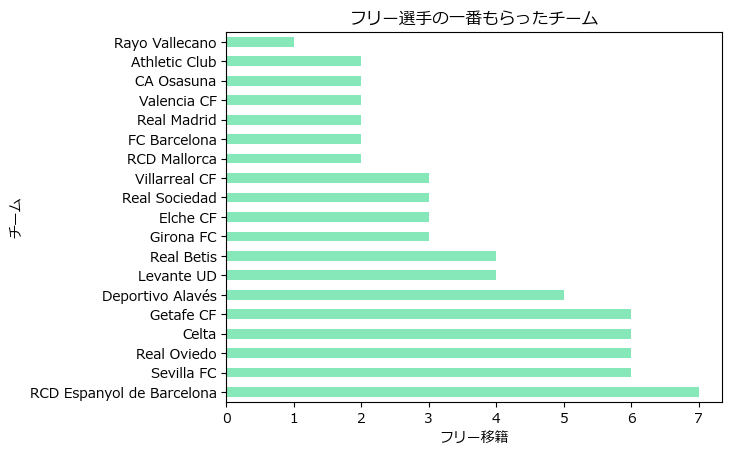

In [23]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Meiryo'
club_counts.plot(kind='barh',color='#86e7b8')
plt.title('フリー選手の一番もらったチーム')
plt.ylabel('チーム')
plt.xlabel('フリー移籍')
plt.show()

In [25]:
club_counts.head()

team_to
RCD Espanyol de Barcelona    7
Sevilla FC                   6
Real Oviedo                  6
Celta                        6
Getafe CF                    6
Name: count, dtype: int64

In [24]:
df1_clean.head()

,Position,Team,Played,Qualify
0,1,Real Madrid,8,Champions League
1,2,FC Barcelona,8,Champions League
2,3,Villarreal CF,8,Champions League
3,4,Real Betis,8,Champions League
4,5,Atlético de Madrid,8,Champions League


In [26]:
club_counts_df = club_counts.reset_index()
club_counts_df.columns = ['Team', 'FreeTransferCount']

In [28]:
df_merged = df1_clean.merge(club_counts_df, on='Team', how='left')
df_merged

,Position,Team,Played,Qualify,FreeTransferCount
0,1,Real Madrid,8,Champions League,2.0
1,2,FC Barcelona,8,Champions League,2.0
2,3,Villarreal CF,8,Champions League,3.0
3,4,Real Betis,8,Champions League,4.0
4,5,Atlético de Madrid,8,Champions League,NaN
5,6,Sevilla FC,8,Europa League,6.0
6,7,Elche CF,8,Europa League,3.0
7,8,Athletic Club,8,Conference League,2.0
8,9,RCD Espanyol de Barcelona,8,NaN,7.0
9,10,Deportivo Alavés,8,NaN,5.0
